## Task description:

Prepare a general analysis of the dataset available at
https://survive-python.readthedocs.io/examples/Channing_House_Dataset.html, and conduct a detailed analysis for the variable describing the age at entry into the nursing home (in years) for women.

a. Test the hypothesis that the expected age of admission to the nursing home is 74 years. Construct confidence intervals for the expected age. Does the value 74 belong to this interval?

b. Find the estimator of the skewness coefficient for the variable describing senior age and construct an appropriate confidence interval for this coefficient. At the 5% significance level, can we conclude that the distribution of the age variable is symmetric? Hint: given confidence intervals at a specified confidence level, conducting a test may involve checking whether 0 lies within the interval.


### 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import math
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import norm
from scipy.stats import ttest_1samp

# Ustawienia wykresów
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

from survive import datasets
from survive import SurvivalData
from survive import KaplanMeier, NelsonAalen

### 2. Data

In [2]:
channing = datasets.channing()
channing.head()

,sex,entry,exit,time,status
resident,,,,,
0,male,782,909,127,1
1,male,1020,1128,108,1
2,male,856,969,113,1
3,male,915,957,42,1
4,male,863,983,120,1


### 3. Descriptive statistics 
for age at the time of moving in (in years) for women

In [3]:
channing['age_year_entry'] = round(channing['entry'] / 12, 1)
female = channing[channing['sex'] == 'female'].reset_index()
female.head()

,resident,sex,entry,exit,time,status,age_year_entry
0,97,female,1042,1172,130,1,86.8
1,98,female,921,1040,119,1,76.8
2,99,female,885,1003,118,1,73.8
3,100,female,901,1018,117,1,75.1
4,101,female,808,932,124,1,67.3


In [4]:
skew_age_female = stats.skew(female['age_year_entry'])
kurt_age_female = stats.kurtosis(female['age_year_entry'])

female_desc = female['age_year_entry'].describe().to_frame().T
female_desc['skewness'] = skew_age_female
female_desc['kurtosis'] = kurt_age_female
female_desc

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age_year_entry,365.0,75.225479,5.70221,61.1,70.9,74.9,79.0,95.0,0.238716,-0.164096


The age distribution appears approximately symmetric, with a median of 74.9 years and only a slight positive skewness. The negative kurtosis indicates a slightly flatter distribution compared to a normal distribution.

### 4. Checking the normality of women's age distribution

#### Histogram


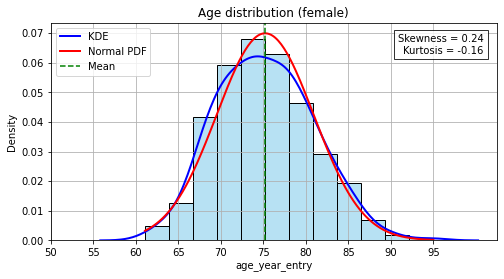

In [5]:
mu = female['age_year_entry'].mean()
sigma = female['age_year_entry'].std()

x = np.linspace(female['age_year_entry'].min(),
                female['age_year_entry'].max(), 200)

pdf = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots()


sns.histplot(
    female['age_year_entry'],
    bins=12,
    stat='density',
    color='skyblue',
    edgecolor='black',
    alpha=0.6,
    ax=ax
)

sns.kdeplot(
    female['age_year_entry'],
    color='blue',
    lw=2,
    ax=ax,
    label='KDE'
)

ax.plot(x, pdf, color='red', lw=2, label='Normal PDF')
ax.axvline(mu, color='green', linestyle='--', label='Mean')

ax.text(
    0.97, 0.95,
    f'Skewness = {skew_age_female:.2f}\nKurtosis = {kurt_age_female:.2f}',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.8)
)
ax.set_xticks(range(50,100,5))
ax.legend(loc='upper left')
ax.set_title('Age distribution (female)')
plt.show()

#### QQ - plot

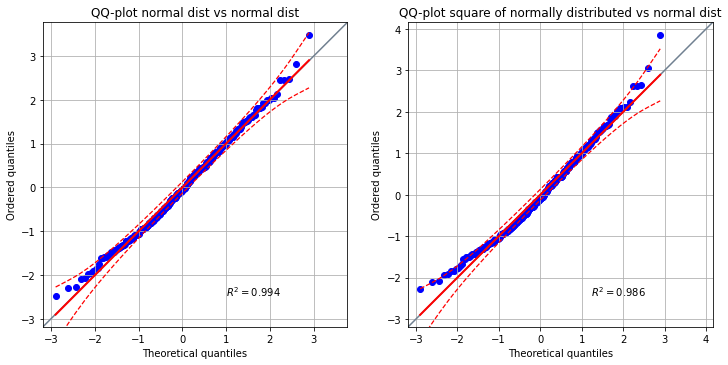

In [6]:
female_age = female['age_year_entry']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1 = pg.qqplot(female_age, dist='norm', ax=ax1, confidence=0.95)
ax1.set_title('QQ-plot normal dist vs normal dist')
ax2 = pg.qqplot(female_age**2, dist='norm', ax=ax2, confidence=0.95)
ax2.set_title('QQ-plot square of normally distributed vs normal dist')
plt.show()

#### Skewness and kurtosis

In [7]:
female_desc[['skewness','kurtosis']]

,skewness,kurtosis
age_year_entry,0.238716,-0.164096


#### Test Shapiro- Wilka

In [8]:
from scipy.stats import shapiro

# Poziom istotności
alpha = 0.05

# Test Shapiro-Wilka dla danych 'x' (rozkład normalny)
statistic_sh_w, p_value = shapiro(female_age)
print(f"Shapiro-Wilk test for female_age: statistic = {statistic_sh_w:.4f}, p-value = {p_value:.4f}.")

if p_value > alpha:
    print(f"There is not enough evidence to reject H0.")
else:
    print("The null hypothesis (H0) is rejected: the female_age data do not appear to come from a normal distribution.")

Shapiro-Wilk test for female_age: statistic = 0.9942, p-value = 0.1788.
There is not enough evidence to reject H0.


The histogram shows that the data is close to a normal distribution. The distribution is symmetric with a slight right skew, as indicated by a skewness coefficient of 0.24. The kurtosis suggests a slight flattening compared to the normal distribution, which implies lower concentration of values around the mean and no strong outliers. Overall, the distribution can be considered approximately normal, confirming its stable and predictable nature.

The QQ-plot confirms a good fit to the normal distribution, with only minor deviations at the extremes. Therefore, the assumption of normality appears reasonable.Since the p-value exceeds the significance level of 0.05, there is insufficient evidence to reject the null hypothesis that the data follow a normal distribution.

Taken together, the graphical and numerical analyses suggest that the distribution of women's age can be considered approximately normal, and the assumption of normality appears reasonable for subsequent statistical analyses.

### 5. Confidence interval analysis and One-sample t-test 

In [9]:
# a. Hypothesis test: expected age of entering a nursing home 74 years
# Construct confidence intervals for the expected age and determine whether 74 falls within this interval.

# H0: age_enter = 74
# H1: age_enter != 74

hypothesized_mean = 74
alpha = 0.05

t_statistic, p_value = stats.ttest_1samp(female_age, hypothesized_mean)

mean_female = np.mean(female_age)
n = len(female_age)
df = n - 1
se = stats.sem(female_age)

# przedział ufności 95%
t_critical = stats.t.ppf(1 - alpha/2, df)

z_left = mean_female - t_critical * se
z_right = mean_female + t_critical * se

print('Sample mean:', mean_female)
print('t statistic:', t_statistic)
print('p_value:', p_value)
print(f"95% Confidence internal: ({z_left:.2f}, {z_right:.2f})")

# sprawdzenie przedziału ufności
if z_left <= hypothesized_mean <= z_right:
    print(f"\nThe expected age of placement in a care home of {hypothesized_mean} years is within the confidence interval. 95% Confidence internal:({z_left:.2f}, {z_right:.2f})")
else:
    print(f"\nThe expected age of placement in a care home of {hypothesized_mean} years is outside the confidence interval. Confidence internal:({z_left:.2f}, {z_right:.2f})")

    
if p_value < alpha:
    print("We reject H0 – the expected age of entering a nursing home for women is significantly different from 74 years.")
else:
    print("There is not enough evidence to reject H0.")  

Sample mean: 75.2254794520548
t statistic: 4.105908308750541
p_value: 4.976080803767659e-05
95% Confidence internal: (74.64, 75.81)

The expected age of placement in a care home of 74 years is outside the confidence interval. Confidence internal:(74.64, 75.81)
We reject H0 – the expected age of entering a nursing home for women is significantly different from 74 years.


An analysis was conducted to examine whether the average age of women at the time of admission to a nursing home is 74 years. The results indicate that the mean age in the sample is 75.23 years, which represents a small but statistically significant deviation from the reference value of 74 years.

The test result (p-value ≈ 0.00005) suggests that the observed difference is not due to random chance, and at a 5% significance level, the null hypothesis of a mean age equal to 74 years should be rejected. In practical terms, this means that women in the studied population enter nursing homes slightly later than assumed in the reference hypothesis.

The 95% confidence interval for the mean age of admission was 74.64 to 75.81 years. Since the hypothesized value of 74 years does not fall within this interval, the confidence interval analysis leads to the same conclusion as the hypothesis test: the average age at admission is significantly different from 74 years. This provides additional evidence that women in the studied population tend to enter nursing homes at a slightly older age than assumed under the null hypothesis.

### 6.Confidence interval analysis – skewness of senior age

In [14]:
# b. Znajdź estymator współczynnika skośności dla zmiennej opisującej wiek seniora oraz odpowiedni przedział ufności dla 
# tego współczynnika. 

senior_age = channing['age_year_entry'].dropna()
n = len(senior_age)

alpha = 0.05

skew_senior_age = stats.skew(senior_age, bias=False)

# standard error
se = np.sqrt(6*n*(n-1)/((n-2)*(n+1)*(n+3)))

z = stats.norm.ppf(1 - alpha/2)
interval_skew = (skew_senior_age - z * se, skew_senior_age + z * se)

print(f"Skewness estimator: ", skew_senior_age)
print(f"Confidence interval for skewness: ",interval_skew)


Skewness estimator:  0.20832582095081345
Confidence interval for skewness:  (-0.014312172332284712, 0.4309638142339116)


At the 5% significance level, we do not reject the null hypothesis that the distribution of senior age is symmetric, since the confidence interval for skewness includes zero.